# Load modules

In [ ]:
from numpy import *
import seaborn as sns
import matplotlib.pyplot as plt

from astropy.cosmology import WMAP9 as cosmo
from astropy.cosmology import FlatLambdaCDM
# Defining cosmology in use
# H0 = 0.68, Omega_m = 0.31
cosmo = FlatLambdaCDM(H0=68, Om0=0.31)

from astropy import coordinates
from astropy import units as u
from astropy import constants as const
from astropy.coordinates import SkyCoord, Distance, match_coordinates_sky, cartesian_to_spherical, spherical_to_cartesian
from astropy.stats import median_absolute_deviation 
from astropy.table import Table, vstack

from scipy.interpolate import interp1d
from scipy.stats import uniform, norm, linregress
from scipy.optimize import curve_fit

import tqdm

In [ ]:
# Installing feature that reads mask file in .ply (uncomment if necessary)
#!pip install pymangle==0.9.1
#import pymangle

In [ ]:
# Install and import HDBSCAN, used for galaxy membership
!pip install hdbscan
import hdbscan

# Install and import KneeLocator, used to locate the galaxy
# density drop, Rc, in the cluster
!pip install kneed
from kneed import KneeLocator

# AME

## select galaxies

In [ ]:
'''
# Given the cluster data, galaxy data, radius, redshift limits
# select galaxies within z_cl +/- Delta_z * (1 + z_cl), and R < radius 
# return: astropy.Table with selected galaxies
'''

def select_galaxies(detcl, data, radius, dz):
  # cluster redshift
  cluster_redshift = detcl['z']

  # galaxies within cluster redshift
  cond = abs(data['z'] - cluster_redshift) < dz*(1+cluster_redshift)
  data_cut = data[cond]

  # distances between cluster and galaxies coordinates:
  c_detec = SkyCoord(detcl['ra'], detcl['dec'], unit='deg') 
  c_data = SkyCoord(data_cut['ra'], data_cut['dec'], unit='deg')

  # SkyCoord.separation: The separation is calculated using the Vincenty formula
  sep = c_data.separation(c_detec)
  sep_kpc = array(tan(sep.radian)*cosmo.angular_diameter_distance(cluster_redshift).to(u.kpc))

  # select galaxies inside radius 
  good_r = (sep_kpc>0) & (sep_kpc < radius) 
  data_cut = data_cut[good_r]

  return data_cut

In [ ]:
'''
# Given the cluster data, galaxy data, radius
# select galaxies within R < radius 
# return: astropy.Table with selected galaxies
'''

def select_galaxies_radius(detcl, data, radius):
  # distances between cluster and galaxies coordinates:
  c_detec = SkyCoord(detcl['ra'], detcl['dec'], unit='deg') 
  c_data = SkyCoord(data['ra'], data['dec'], unit='deg')

  # SkyCoord.separation: The separation is calculated using the Vincenty formula
  sep = c_data.separation(c_detec)
  sep_kpc = array(tan(sep.radian)*cosmo.angular_diameter_distance(detcl['z']).to(u.kpc))

  # select galaxies inside radiusin kpc
  good_r = (sep_kpc>0) & (sep_kpc < radius) 
  data_cut = data[good_r]

  return data_cut

## random redshift

In [ ]:
'''
# Given a galaxy catalog
# Generate a random redshift value from galaxy probability density function PDF(z)
# return: random redshift
'''

def random_redshift(data_cut):
  # redshift array on which PDFs were estimated
  dz = 0.01
  z = arange(0.,0.61, dz)

  # for each galaxy draw a random value 
  random_z = []
  for gal in range(len(data_cut)):
    #random value from distribution (uses normilized PDF)
    random_zi = random.choice(z, p=data_cut['PDF'][gal]/sum(data_cut['PDF'][gal]))
    random_z += [random_zi]

  return random_z 

## peculiar velocity

In [ ]:
'''
# Given cluster data, galaxy random redshift
# calculates the galaxies peculiar velocity
# return: peculiar velocity
'''

def peculiar_velocity(detcl, z):
  # cluster redshift
  z_cl = detcl['z']

  # galaxy peculiar velocity
  v_gal = const.c.to('km/s').value * (z - z_cl) / (1 + z_cl) 

  return v_gal

## velocity dispersion

In [ ]:
'''
# Given galaxy velocity, n sigma clipping 
# calculates the velocity dispersion
# return: mean velocity, dispersion
'''

def velocity_dispersion_3sigma(v_gal, n):

  # For sigma clipping
  # initial median value galaxies peculiar velocity
  v_mean_i = 1
  # median value
  v_mean = mean(v_gal)
  # standard deviation
  sigma_cl = std(v_gal)

  # while difference greater than 1e-5
  i = 0
  while abs((v_mean - v_mean_i) / v_mean_i) > 1e-5:
    # clipping condition
    cond = abs(v_gal-v_mean) < n*sigma_cl
    # new values
    v_gal = v_gal[cond]
    v_mean_i = v_mean
    v_mean = mean(v_gal)
    sigma_cl = std(v_gal)
    # counter
    i=i+1

  return v_mean, sigma_cl

## HDBSCAN label check

In [ ]:
'''
# Given HDBSCAN.unique_labels, HDBSCAN.clusterer_probs, galaxy data, cluster
# if identified more than one label, identify the set closest to the cluster center
# ''if substructure = 1'': take each label as a subtructure and calculate coordinates, 
# redshift, richness param and mean distance, save as a subproduct 
# return: HDBSCAN.unique_labels closest to the cluster center
'''

def label_check(unique_labels, clusterer_probs, data_cut, cluster, substructure=0):

  # saves the mean distance from mnultiple labels
  dist_check = []

  # possible labels (introduce more if needed)
  b2 = [0,1,2,3,4,5]

  # from the galaxy identification labels creates array with one value each
  unique_labels_check = array(list(set(unique_labels).intersection(b2)))

  if len(unique_labels_check) > 1:

    # distances between cluster and galaxies coordinates:
    c_detec = SkyCoord(cluster['ra'],cluster['dec'], unit='deg') 
    c_data = SkyCoord(data_cut['ra'],data_cut['dec'], unit='deg')
    
    # SkyCoord.separation: The separation is calculated using the Vincenty formula
    sep = c_data.separation(c_detec)
    sep_kpc = array(tan(sep.radian)*cosmo.angular_diameter_distance(data_cut['random_z']).to(u.kpc))
    data_cut['sep_kpc'] = sep_kpc

    # for each galaxy label, calculate median distances
    for ij in range(len(unique_labels_check)):
      dist_check += [(mean(data_cut['sep_kpc'][unique_labels == unique_labels_check[ij]]),ij)]

    # label with minimum distance
    cond_label = unique_labels == min(dist_check)[1]

    if substructure == 1:
      # for each galaxy label, calculate coordinates, redshift, richness param
      # and mean distance. Saves as possible substructure
      for label in range(1, len(dist_check)):  
        conds = sorted(dist_check)[label]
        cond_label = unique_labels == conds[1]

        # calculate median coordinates, redshift, richness param 
        ra_m, dec_m, z_m, rich, dist_m = calc_coord_z_pond(data_cut[cond_label], 
                                                    clusterer_probs[cond_label], 
                                                    cluster)
        # save to substructures Table 
        substructures.add_row((ra_m, dec_m, z_m, rich, dist_m, cluster['ID']))


  else: cond_label = unique_labels == 0

  return cond_label

In [ ]:
'''
# Given selected galaxies (HDBSCAN.unique_labels), HDBSCAN.clusterer_probs, cluster
# calculate mean coordinates, redshift, richness param and distance weighted by 
# the galaxies probabilities HDBSCAN.clusterer_probs 
# Return: mean coordinates, redshift, distance from new center, rich as sum(HDBSCAN.clusterer_probs)
'''

def calc_coord_z_pond(gals, clusterer_probs, cluster):

  # richness proxy given by clusterer_probs
  rich = sum(clusterer_probs)

  # mean galaxies redshift
  z_m = [sum(gals['z']*clusterer_probs)/sum(clusterer_probs)]

  # mean galaxies coordinates
  a = SkyCoord(gals['ra'], gals['dec'], unit='deg')
  c0 = spherical_to_cartesian(10, a.dec.rad, a.ra.rad)

  ra_m2 = [sum(c0[0]*clusterer_probs)/sum(clusterer_probs)]
  dec_m2 = [sum(c0[1]*clusterer_probs)/sum(clusterer_probs)]
  d_volta2 = [sum(c0[2]*clusterer_probs)/sum(clusterer_probs)]

  # distance between new center defined by the galaxies and cluster center
  c2 = cartesian_to_spherical(ra_m2, dec_m2, d_volta2)

  d2 = SkyCoord(ra=c2[2], dec=c2[1])

  c_detec1 = SkyCoord(d2.ra.deg, d2.dec.deg, unit='deg')
  c_detec = SkyCoord(cluster['RA'], cluster['DEC'], unit='deg')

  # SkyCoord.separation: The separation is calculated using the Vincenty formula
  sep = c_detec1.separation(c_detec)
  # returns distance in kpc
  dist_m = array(tan(sep.radian)*cosmo.angular_diameter_distance(cluster_catalog['z'][i]).to(u.kpc))

  return d2.ra.deg[0], d2.dec.deg[0], z_m[0], rich, dist_m[0]

## hbdscan run

In [ ]:
'''
# Given a galaxies catalog, a cluster, redshift width, enclosed radius, number of .
# runs (default = 100), parameters from relation true members x FAE richness (gradient, intercept),
# FAE richness, define is_mock = 0, do_plot=0, do_prints=0, do_print_stats=0 (0 = false, 1 = true) 
# the galaxies probabilities HDBSCAN.clusterer_probs 
# return: mean coordinates, redshift, distance from new center, rich as sum(HDBSCAN.clusterer_probs)
'''

def hbdscan_run(data, cluster, dz, radius, N_runs, gradient, intercept, cluster_rich,
                substructure=0, is_mock=0, do_plot=0):

  # cluster identification
  c_data = SkyCoord(data['ra'],data['dec'], unit='deg')
  c_detec = SkyCoord(cluster['ra'],cluster['dec'], unit='deg') 

  # selecting galaxies within radius
  data_cut = select_galaxies_radius(cluster, data, radius)

  # Mock memebership 
  if is_mock==1:
    # cluster id
    cond_id = cluster['haloId']
    # creates a column in galaxy catalog and assign membership as 1
    data['member'] = [0]*len(data)
    data['member'][data['haloId']==cond_id] = 1 

  # Control data for membership analysis (data within Rc and dz)
  data_cut_control = data_cut
  cond = abs(data_cut_control['z']-cluster['z']) < dz 
  data_cut_control = data_cut_control[cond]

  # creates a column for HDBSCAN probabilities
  data_cut_control['member_ame'] = [0.]*len(data_cut_control)

  # Galaxy identification ids
  gal_num2 = [] 

  # Number of expected galaxies HDBSCAN.min_cluster_size. Must be an integer!
  # depends on the cluster FAE richness, comes from simulation data. 
  cluster_size_f =  gradient*cluster_rich+intercept
  # limit to be considered a valid detection 
  # comes from std FAE richness applied in random coordinates
  # If cluster size is lower than 2, fixes it in 2 
  if (cluster_size_f>=0.6) & (cluster_size_f<2): cluster_size = 2
  else:  cluster_size = int(cluster_size_f)

  if cluster_size > 1: 
    # if no galaxies found in around cluster center
    if len(data_cut_control)==0: print('no galaxies within Rc')

    # number of repetitions for probability estimate
    for j in range(N_runs):

      # estimating a random redshift value with PDFs
      data_cut['random_z'] = random_redshift(data_cut)

      # Compute peculiar velocity and select galaxies
      data_cut['vp'] = peculiar_velocity(cluster['z'], data_cut['random_z'])

      # Mean velocity to remove galaxies with sigma_v > 3sigma
      v_mean, sigma = velocity_dispersion_3sigma(data_cut['vp'], 3)

      # If we have enough galaxies after cuts, else: nan
      if len(data_cut[abs(data_cut['vp']-v_mean) < 3*sigma])>1:
        data_cut = data_cut[abs(data_cut['vp']-v_mean) < 3*sigma]
      
        # Generates HDBSCAN format sample data 
        X2 = []
        for i in range(len(data_cut4)):
          X2 += [[(data_cut4['ra'][i]-cluster['ra']),
                  data_cut4['dec'][i]-cluster['dec']]]
        X2 = array(X2)
    
        # Run HDBSCAN allowing a single custer
        clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, 
                                    gen_min_span_tree=True, 
                                    allow_single_cluster=True)
        clusterer.fit(X2)

        # Plotting results
        if do_plot ==1:
          # Plot cluster members
          plt.scatter(X2.T[0], X2.T[1], color='k')
          palette = sns.color_palette("husl", 9)
          cluster_colors = [sns.desaturate(palette[col], sat)
                            if col >= 0 else (0.5, 0.5, 0.5) for col, sat in
                            zip(clusterer.labels_, clusterer.probabilities_)]
          plt.scatter(X2.T[0], X2.T[1], c=cluster_colors)
          if is_mock == 1:
            plt.plot(data_cut_control['ra'][data_cut_control['member']==1]-cluster['ra'],
                    data_cut_control['dec'][data_cut_control['member']==1]-cluster['dec'],
                    'o', markerfacecolor='none', color='k', ms=10, label='true member')
            plt.plot(X2.T[0][data_cut4['member']==1], X2.T[1][data_cut4['member']==1],
                    'o', markerfacecolor='none', color='cyan', ms=10, label='selected true member')
          plt.legend()
          plt.show()

        # Take only the bunch of galaxies closest to the cluster center
        if substructure==1: 
          cond_label = label_check(clusterer.labels_, clusterer.probabilities_, 
                                 data_cut, cluster, substructure=1)
        else: 
          cond_label = label_check(clusterer.labels_, clusterer.probabilities_, 
                                 data_cut, cluster)

        # Saves galaxy ids for further count
        for i1 in range(len(data_cut['galaxyId'][cond_label])):
          gal_num2.append(data_cut['galaxyId'][cond_label][i1])


  # Counts how many times a galaxy apears as a cluster member
  Prob = []
  for l in data_cut_control['galaxyId']:
    Prob += [gal_num2.count(l)/N_runs]

  # Save probability into the data
  data_cut_control['member_hdbsdcan'] = Prob
  data['clusterID'][list(data_cut_control['l_id'])] = cluster['haloId']
  
  # Saves mock galaxies within Rc
  if is_mock==1: data['mem'][list(data_cut_control['l_id'])] = mem

  return data_cut_control

   
import warnings
warnings.filterwarnings("ignore")

## random catalog

In [ ]:
'''
# Given a redshift value (or array), and data catalog (ra, dec) 
# creates an astropy.Table with random coordinates, and selected zs 
# define table size, if redshift array: must be of the same size
# return: random coordinates catalog
'''

def random_catalog(zs, catalog, size = 50):
  
  random_detec = Table()

  # generate random positions
  if len(zs)>1: random_detec['z'] = zs
  else: random_detec['z'] = [zs]*size
  random_detec['ra'] = random.uniform(low=min(catalog['ra']),  high=max(catalog['ra']),  size=size)
  random_detec['dec']= random.uniform(low=min(catalog['dec']), high=max(catalog['dec']), size=size)

  # if using .ply mask, uncomment next lines
  #npoins = 50
  #good_m = m.contains(random_detec['ra'], random_detec['dec'])
  #random_detec=random_detec[good_m][:npoins]
  # verify if final catalog has enough points after mask
  #if len(random_detec) < npoins: print('catalog length lower than %d'%npoins)

  return random_detec


# FAE

## Richness code

In [ ]:
'''
# Given a galaxy catalog, cluster catalog, redshift width, enclosed radius, 
# field galaxies density function (popt_mode, popt_err)
# estimate richness as the sum of the galaxy probability of being at the cluster z +/- dz
# return: richness, err, snr
'''

def richness_rv(data, detections, deltaz, radius, popt_mode, popt_err):

  #cluster redshift
  cluster_redshift = detections['z']

  #distances between cluster and galaxies:
  c_data = SkyCoord(data['ra'],data['dec'], unit='deg')
  c_detec = SkyCoord(detections['ra'],detections['dec'], unit='deg') 

  #SkyCoord.separation: The separation is calculated using the Vincenty formula
  sep = c_data.separation(c_detec)
  sep_kpc = array(tan(sep.radian)*cosmo.angular_diameter_distance(cluster_redshift).to(u.kpc))

  if len(sep[sep_kpc < radius])>0:
    #select galaxies inside radius 
    good_r = (sep_kpc > 0) & (sep_kpc < radius) 
    data_cut = data[good_r]

    # test coordinates againts mask/borders, estimate cluster area
    cluster_area = area_outside_mask(c_detec, cluster_redshift, radius)
    
    #redshift limits
    zlim = [cluster_redshift - deltaz*(1.+cluster_redshift), cluster_redshift + deltaz*(1.+cluster_redshift)]
 
    #Galaxies probabilities within zlim
    prob = prob_calc(data_cut, zlim)

    # estimate richness, err, snr given the field galaxies
    rich = sum(prob) - cluster_area[0]*func(cluster_redshift, *popt_mode)
    err = sqrt(sum(prob) + (cluster_area[0]*func(cluster_redshift, *popt_err))**2)
    if rich < 0: snr = 0
    else: snr = (rich/err)**2

  # if no galaxies within the cluster center
  else:
    rich = 0
    err = 0
    snr = 0
    
  return rich, err, snr

## probability calculation

In [ ]:
'''
# Given galaxy data, redshift limits
# calculates the probability of membership of a galaxy inside a redshift limit.
# return: an array of probabilities
'''
def prob_calc(data_cut, zlim):
  # final probability array
  prob=[]

  for gal in range(len(data_cut)):
    # redshift array on which PDFs were estimated
    z = arange(0.,.602,0.002)

    # calculating cdf from pdf
    pdf = data_cut[gal]['PDF']
    cdf = cumsum(pdf)
    cdf = cdf/cdf[-1]

    #cdf interpolation
    f0 = interp1d(z,cdf)

    #function values in the z limits
    if zlim[0] < z[0]: prob_x1=0
    else: prob_x1 = f0(zlim[0])
    if zlim[1] < z[0]: prob_x2=0
    elif zlim[1] > z[-1]: prob_x2 = f0(z[-1])
    else: prob_x2 = f0(zlim[1])

    # prob = cdf(x2)-cdf(x1)
    prob += [prob_x2 - prob_x1]
    
  return array(prob)

## kpc to degree

In [ ]:
'''
# Given radius in kpc, and redshift
# calculates the radius in degrees
# return: radius in degrees
'''

def kpc_to_degree(radius,redshift):
	return degrees(arctan(radius/cosmo.angular_diameter_distance(redshift).to(u.kpc).value))

## area outside mask

In [ ]:
'''
# Given cluster coordinates (x_center, y_center), redshift, and enclosed radius
# creates a distribuition of N points inside the radius and test againts mask
# return: corresponding area outside the mask region.
'''

def area_outside_mask(cluster_coordinates, cluster_redshift, r_ring_max, r_ring_min=0):
  #number of random points 
  N = 5000

  #centering coordinates
  x_center = cluster_coordinates.ra.value
  y_center = cluster_coordinates.dec.value

  #circular distribuition of points
  ra = []
  dec= []

  r = kpc_to_degree(r_ring_max, cluster_redshift)

  for i in range (0,N):
    theta = 2*pi*random.random()
    eta_sqrt = sqrt(random.random())
    rad = 2*r*eta_sqrt
    ra.append(x_center + rad*cos(theta))  
    dec.append(y_center + rad*sin(theta))	

  ra = array(ra)
  dec= array(dec)

  #test arrays of ra,dec points against box boundaries
  c_data = SkyCoord(ra, dec, unit='deg')

  #SkyCoord.separation: The separation is calculated using the Vincenty formula
  sep = c_data.separation(cluster_coordinates)
  sep_kpc = array(tan(sep.radian)*cosmo.angular_diameter_distance(cluster_redshift).to(u.kpc))
  
  # inside enclosed radius
  good_rmax = (sep_kpc < r_ring_max)
  # if minimum is required
  good_rmin = (sep_kpc > r_ring_min) 

  # box boundaries (max/min of the galaxies coordinates)
  # if .ply mask use simply: good_m = m.contains(ra, dec) 
  good_ra_max = (ra <  max(data['ra']))
  good_ra_min = (ra > min(data['ra']))
  good_dec_max = (dec < max(data['dec']))
  good_dec_min = (dec > min(data['dec']))
  good_m = [good_ra_max & good_ra_min & good_dec_max & good_dec_min]


  good2 = good_m & good_rmax & good_dec_min

  # ring area 
  circle_area = pi*r**2
  estimated_area = circle_area*len(ra[good2])/len(ra[good_rmax & good_dec_min])

  return estimated_area, ra[good2], dec[good2]

## field galaxies density

In [ ]:
'''
# Given redshift of reference, radius, and galaxy catalog (ra, dec)
# Calculate the field density through the survey area
# define do_plot, if 0 = false, 1 = true
# return: density at redshift
'''
  
def var_redshift(redshift, radius, data, do_plot=0):
  # take radius in degrees
  radius_degree = degrees(arctan(radius/cosmo.angular_diameter_distance(redshift).to(u.kpc).value))

  # define a step proportional to cluster area
  step = radius_degree*sqrt(pi)
  step_ra = degrees(radians(step)/cos(radians(median(data['dec']))))

  # devide survey area
  ra_lim = arange(min(data['ra'])-step_ra/2, max(data['ra']), step_ra)
  dec_lim= arange(min(data['dec'])-step/2, max(data['dec']), step)

  #redshift limits
  deltaz = 0.05
  zlim = [redshift-deltaz*(1.+redshift), redshift+deltaz*(1.+redshift)]

  # use largers steps if the survey area is large
  if redshift < 0.1: step2 = 2
  if redshift < 0.2: step2 = 4
  if redshift < 0.3: step2 = 6
  if redshift < 0.4: step2 = 8
  else: step2 = 3

  N_gal,tot_area=[], []

  # plot galaxies
  if do_plot==1: plt.plot(data['ra'], data['dec'], '.')

  # for each smaller area
  for i in range(1, len(ra_lim), step2):
    for j in range(1, len(dec_lim), step2):
      # coordinate limits
      cond_ra  = (abs(data['ra'] - ra_lim[i]) < step_ra/2)
      cond_dec = (abs(data['dec'] - dec_lim[j]) < step/2)
      # select data within limits
      data_cut = data[cond_ra & cond_dec]    
      # calculate number of galaxies within dz and area
      N_gal += [sum(prob_calc(data_cut, zlim))]
      tot_area += [step_ra*step]
            
      if do_plot==1: plt.plot(data['ra_rot'][cond_ra & cond_dec],data['dec_rot'][cond_ra & cond_dec],'.')

  if do_plot==1: 
    plt.grid()
    plt.show()

  # calculate density
  N_gal, tot_area = array(N_gal), array(tot_area)
  dens = N_gal[cond]/tot_area[cond]
  
  return array(dens[dens>1e-5]) 

In [ ]:
# polinomial function for field density interpolation 
def func(x, a, b, c, d, e):
    return a+b*x+c*x**2+d*x**3+e*x**4#+f*x**5

In [ ]:
'''
# Given enclosed radius, galaxy catalog, stats name
# calculates the the 3 sigma statistics with density
# saves the final result for future use, define do_plot=1 0=false, 1=true
# return: interpolation result (popt_mode, popt_err)
'''

def survey_area_statistics(radius_att, data, stats, do_plot=1):
  # redshift range
  z = arange(.04,.5,.05)

  # array
  mode = []
  err = []

  for k in tqdm.tqdm(range(len(z))):
    # calculate the field density
    tot_dens = var_redshift(z[k], radius_att, data)
    # for plotting initial array
    if do_plot==1: plot tot_dens2 = tot_dens

    # initial value for 3 sigma clipping
    median2 = 1
    while abs((median(tot_dens)-median2)/median2) > 0.002:
      std_v = median_absolute_deviation(tot_dens)
      # iterate initial value
      median2 = median(tot_dens)
      # cut condition
      cond = (tot_dens > median(tot_dens)-3*std_v) & (tot_dens < median(tot_dens)+3*std_v)
      # final value
      tot_dens = tot_dens[cond]

    # calculate median density value
    mode += [median(tot_dens)]
    # err
    err += [median_absolute_deviation(tot_dens)]

    if do_plot==1:
      plt.title('z=%.3f ~ n quadrados:%d'%(z[k],len(tot_dens)))
      plt.axvline(mode[k], ls=':',color='k')
      bins = histogram(hstack((tot_dens2,tot_dens)), bins=150)[1]
      plt.hist(tot_dens2, bins = bins)
      plt.hist(tot_dens, bins = bins)
      plt.xlabel('N_gal/area')
      plt.ylabel('Counts')
      plt.show()

  # interpolation
  popt_mode, pcov_mode = curve_fit(func, z, mode)
  popt_err, pcov_err = curve_fit(func, z, err)

  #writing to file
  z, mode, err = array(z), array(mode), array(err)
  out    = transpose([z, mode, err])
  header = "z      median      err"
  savetxt('%s'%stats, out, fmt='%1.6e', header=header)

  if do_plot==1: # plot results
    plt.plot(z, mode, '.', label='median density')
    plt.plot(z, func(z,*popt_mode),':', label='density fit')

    plt.plot(z, err, '.', label='err')
    plt.plot(z, func(z,*popt_err),':', label='err fit')

    plt.xlabel('redshift')
    plt.ylabel('density counts/area')
    plt.title('Field contribution')
    plt.show()

  return popt_mode, popt_err


# Rc

In [ ]:
'''
# Given a galaxies catalog, and a cluster (ra, dec, z)
# find the density break in the radial galaxy density profile
# define do_plot, if 0 = false, 1 = true
# return: Rc
'''

def radial_density_knee(data, cluster, do_plot=0):
  # radial density break, Rc
  knee = []

  # Select galaxies around cluster center, and redshift width
  dz = 0.05
  outer_radius = 1500 #kpc
  data_cut = select_galaxies(cluster, data, outer_radius, dz)

  # cilinder depth
  hc = 2*dz*(1+cluster['z'])

  # data coordinates
  c_data = SkyCoord(data_cut['ra'],data_cut['dec'], unit='deg')
  c_detec = SkyCoord(cluster['ra'],cluster['dec'], unit='deg') 

  # Distance between cluster center and galaxy coordinates
  sep = c_data.separation(c_detec)
  sep_kpc = array(tan(sep.radian)*cosmo.angular_diameter_distance(cluster['z']).to(u.kpc))

  # anulus radius
  r1gas = 450.	                        # initial radius
  rmaxgas = 5000	                      # final radius for steps	  
  logdrgas = (log10(rmaxgas/r1gas))/20  # log scale steps
  rgas = sep_kpc                        # array with galaxy distances

  x1 = []	  # radius
  y1 = []	  # density
  
  A1 = 0    # intial area 

  # test against borders
  r = kpc_to_degree(outer_radius, cluster['z'])
  good_ra_max = (max(data_cut['ra'])+r <  max(data['ra']))
  good_ra_min = (min(data_cut['ra'])-r > min(data['ra']))
  good_dec_max = (max(data_cut['dec'])+r < max(data['dec']))
  good_dec_min = (min(data_cut['dec'])-r > min(data['dec']))

  if good_ra_max & good_ra_min & good_dec_max & good_dec_min: A2 = pi*r1gas**2
  else: A2 = area_outside_mask(c_detec, cluster['z'], r1gas)[0]  

    while r1gas < outer_radius:
      # outer radius iteration 
      r2gas=10**(log10(r1gas)+logdrgas)

      # measures cilinder volume
      if good_ra_max & good_ra_min & good_dec_max & good_dec_min: A1 = pi*r2gas**2
      else: A1 = area_outside_mask(c_detec, cluster['z'], r2gas)[0]
      v1 = (A1-A2)*hc**2	
      A2 = A1    

      # selec data inside radius data conditions    
      cond = argwhere( (rgas>=r1gas) & (rgas<=r2gas) ).flatten()	
      Rhogas = len(data_cut[cond])/v1	
      rgas1=(r1gas+r2gas)/2.

      # Ensures a valid density
      if Rhogas > 0:
        y1.append(Rhogas)
        x1.append(rgas1)	

      step = 10
      # inner radius iteration 
      r1gas= r1gas + step


  # takes as a knee a convex curve, decreasing.
  # skips first value 
  if len(x1)> 0:
    kneedle = KneeLocator(x1[1:], y1[1:], curve="convex", direction="decreasing")
    knee = kneedle.knee
    else: knee = 450.           # take 450 if there is no valid density
  if knee is None: knee = 450.  # take 450 if KneeLocator wasn't able to find any break

  if do_plot == 1: # if true, plot radial density and detected break
    plt.axvline(kneedle.knee,ls=':',color='b', label='%.2f'%kneedle.knee)
    plt.semilogy(x1,y1,'.-', color='k',alpha=1)
    plt.legend()
    plt.show()

  return knee

# Run

In [ ]:
'''
# Given the cluster catalog, galaxy catalog, catalog name, initial iteration
# calculate cluster_catalog probabilities and subproducts as richness and optical luminosity
# define subs=1 to find substructures within Rc, 0 = false, 1 = true
# return: cluster_catalog Table with memberships, and subproducts
'''

def run(cluster_catalog, data2, catalog_name, init=0, subs=1):
  #-----------------------------------
  if init ==0:
    # data new columns for code
    data2['l_id'] =  arange(len(data2))
    data2['Prob'] =  [99.9]*len(data2)
    data2['clusterID'] =  [99.9]*len(data2)
    data2['galaxyId'] =  arange(len(data2))

    # catalog new columns
    #cluster_catalog['knees'] = [99.9]*len(cluster_catalog)
    cluster_catalog['R_fae'] = [99.9]*len(cluster_catalog)
    cluster_catalog['R_fae_err'] = [99.9]*len(cluster_catalog)
    cluster_catalog['R_ame'] = [99.9]*len(cluster_catalog)
    cluster_catalog['R_ame_err'] = [99.9]*len(cluster_catalog)
    cluster_catalog['opt_lum'] = [99.9]*len(cluster_catalog)
    cluster_catalog['opt_lum_err'] = [99.9]*len(cluster_catalog)
    #cluster_catalog['opt_mass_hdbs'] = [99.9]*len(cluster_catalog)
    #cluster_catalog['opt_mass_hdbs_err'] = [99.9]*len(cluster_catalog)

    # Table initialization for substructure
    if subs == 1:
      substructures = Table()
      substructures['ra'] = [0.]
      substructures['dec'] = [0.]
      substructures['z'] = [0.]
      substructures['rich'] = [0.]
      substructures['center_dist'] = [0.]
      substructures['cluster_ID'] = [0.]

  #-----------------------------------
  # init = reestart point if needed (default=0)
  for i in tqdm.tqdm(range(init, len(cluster_catalog))):

    # firts calculate knee radius (full galaxy data) 
    knee = cluster_catalog['Rc'][i]

    # FAE --------
    deltaz = 0.05
    rich, err, snr = richness_rv2(data2, cluster_catalog[i], deltaz, knee, popt_mode, popt_err)
    cluster_catalog['R_fae'][i] = rich

    # AME -------
    out_data = hbdscan_run(data2, cluster_catalog[i], 0.05, knee, 50, 0.5292105368716316, 
                           0.026652401872489406, rich, substructure=subs)
    
    # subproducts from probabilistic membership: richness, optical luminosity, ...
    cluster_catalog['R_ame'][i]     = sum(out_data['member_hdbsdcan'])
    cluster_catalog['opt_lum'][i]  = sum(out_data['member_hdbsdcan']*(10**(0.4*(4.42-out_data['M']))))
    #cluster_catalog['opt_mass_hdbs'][i] = sum(out_data['member_hdbsdcan']*out_data['stellar_mass']*10**10)

    # produce random catalog for error assignment
    size = 50
    random_detec2 = random_catalog(cluster_catalog[i]['z'], cluster_catalog, size) 

    rich_r1, rich_r2 = [], []  
    opt_lum_err, opt_mass_err = [] ,[]
    
    for ID_r in range(len(random_detec2)):
      rich, err, snr = richness_rv2(data2, random_detec2[ID_r], deltaz, knee, popt_mode, popt_err)
      rich_r1 += [rich]

      data_cut = hbdscan_run(data2, random_detec2[ID_r], deltaz, knee, 50, 0.5292105368716316, 
                             0.026652401872489406, rich, substructure=0)
      
      rich_r2 += [sum(data_cut['member_hdbsdcan'])]
      opt_lum_err += [sum(data_cut['member_hdbsdcan']*(10**(0.4*(4.42-data_cut['M']))))]
      #opt_mass_err += [sum(data_cut['member_hdbsdcan']*data_cut['stellar_mass']*10**10)]

    # Error is calculated as the standard error of the mean
    cluster_catalog['R_fae_err'][i] = std(rich_r1)/sqrt(len(rich_r1)-1)
    cluster_catalog['R_ame_err'][i] = std(rich_r2)/sqrt(len(rich_r1)-1)
    cluster_catalog['opt_lum_err'][i] = std(opt_lum_err)/sqrt(len(rich_r1)-1)
    #cluster_catalog['opt_mass_hdbs_err'][i] = std(opt_mass_err)

    if i%200 == 0: # temporary saving
      cluster_catalog.write('%s/%s_%s.fits'%(path, catalog_name, init), format='fits', overwrite=True)
      data2.write('%s/data_%s_%s.fits'%(path, catalog_name, init), format='fits', overwrite=True)
      if subs==1: substructures.write('%s/substructures_%s_%s.fits'%(path,catalog_name,init), format='fits', overwrite=True)

  # final saving
  cluster_catalog.write('%s/%s_%s.fits'%(path, catalog_name, init), format='fits', overwrite=True)
  data2.write('%s/data_%s_%s.fits'%(path, catalog_name, init), format='fits', overwrite=True)
  if subs==1: substructures.write('%s/substructures_%s_%s.fits'%(path,catalog_name,init), format='fits', overwrite=True)

  return cluster_catalog

# Example run

In [ ]:
# load galaxy data

path = '.'
data = Table.read('%s/data.fits'%path, format='fits')
data['r_mag'] = data['r_auto']
data['z'] = data['zml']
data['M'] = data['r_mag']-5*log10(cosmo.comoving_distance(data['zml']).to('pc').value)+5
#data['galaxyId'] = data['ID']
print(data.columns)

coords=[]
for i in range(len(data['ra'][::50])):
  coords+=[(data['ra'][i],data['dec'][i])]

<TableColumns names=('ID','RA','ra','dec','r_auto','zml','PROB_GAL','PDF','r_mag','z','M')>


## m cut --> M<-20.25

run `survey_area_statistics()` for field density estimation within 0 < z < 0.5

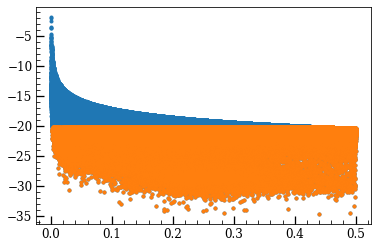

In [ ]:
plt.plot(data['z'],data['M'],'.') 
cond =  data['M']< -20.25
plt.plot(data['z'][cond],data['M'][cond],'.') 
plt.show()

  0%|          | 0/9 [00:00<?, ?it/s]

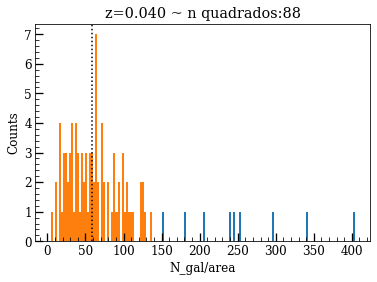

 11%|█         | 1/9 [00:03<00:30,  3.81s/it]

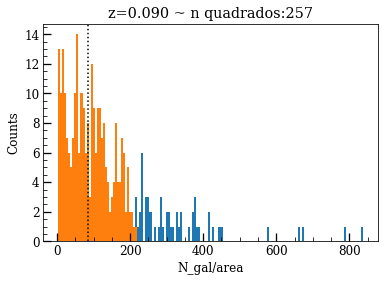

 22%|██▏       | 2/9 [00:07<00:24,  3.52s/it]

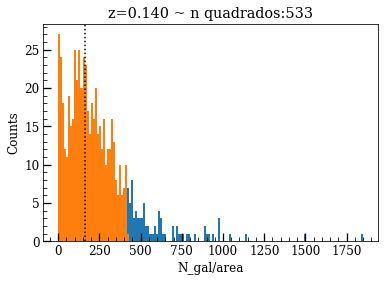

 33%|███▎      | 3/9 [00:12<00:25,  4.20s/it]

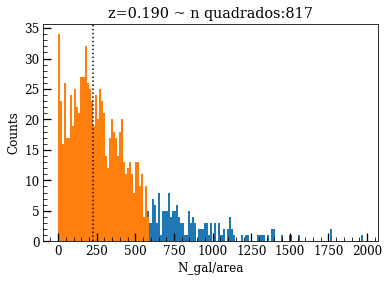

 44%|████▍     | 4/9 [00:17<00:23,  4.67s/it]

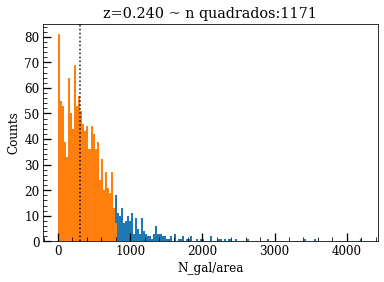

 56%|█████▌    | 5/9 [00:25<00:23,  5.99s/it]

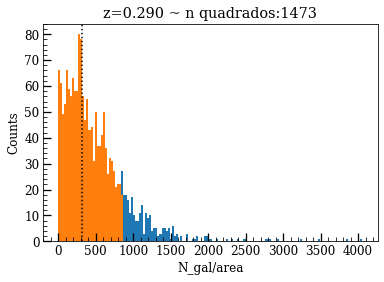

 67%|██████▋   | 6/9 [00:34<00:21,  7.00s/it]

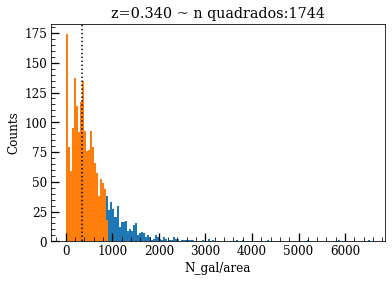

 78%|███████▊  | 7/9 [00:46<00:16,  8.42s/it]

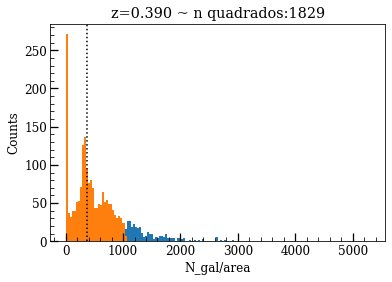

 89%|████████▉ | 8/9 [00:58<00:09,  9.64s/it]

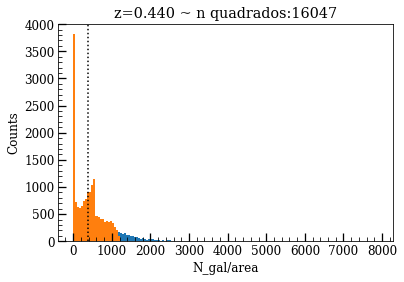

100%|██████████| 9/9 [02:31<00:00, 16.81s/it]


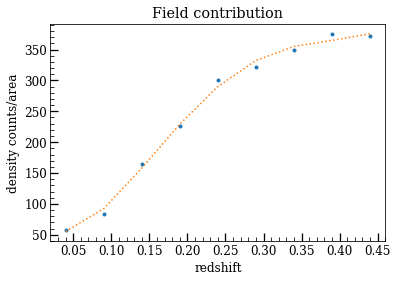

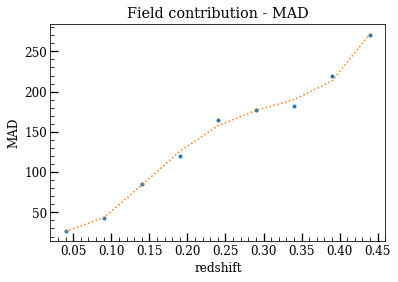

(array([    67.21525287,   -922.03101932,  17794.94834135, -53971.06033017,
         49796.302851  ]),
 array([ 4.94373360e+01, -1.16140629e+03,  1.67950499e+04, -5.69143642e+04,
         6.21688822e+04]))

In [ ]:
data2 = data[cond]
survey_area_statistics(500, data2, 'stats_20')


In [ ]:
# save interpolation results in a separated array
popt_mode, popt_err = (array([    67.21525287,   -922.03101932,  17794.94834135, -53971.06033017, 49796.302851  ]),
                       array([ 4.94373360e+01, -1.16140629e+03,  1.67950499e+04, -5.69143642e+04, 6.21688822e+04]))

##random

Test initial configuration over a randomic catalog. Richness results should result in zero for R$_{AME}$ and oscilates within zero for R$_{FAE}$

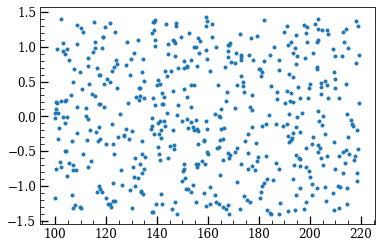

In [ ]:
size = 500
zs = random.uniform(low=0.05, high=.45, size=size)
random_detec = random_catalog(zs, catalog, size = size) 

plt.plot(random_detec['ra'],random_detec['dec'],'.')
plt.show()

In [ ]:
# apply mag cut
cond =  data['M']< -20.25
data2 = data[cond]

# initiate var -----
rich_hdbs_r = []
richs_r =[]

# function parameters for field density
popt_mode, popt_err = (array([    67.21525287,   -922.03101932,  17794.94834135, -53971.06033017, 49796.302851  ]),
                       array([ 4.94373360e+01, -1.16140629e+03,  1.67950499e+04, -5.69143642e+04, 6.21688822e+04]))

# run FAE and AME
for i in tqdm.tqdm(range(len(random_detec))):
  deltaz = 0.05
  # FAE richness
  rich, err, snr = richness_rv2(data2, random_detec[i], deltaz, random_detec['knee'][i], popt_mode, popt_err)
  richs_r += [rich]
  
  # AME richness
  out_data = hbdscan_run(data2, random_detec[i], 0.05, random_detec['knee'][i], 50, 0.5292105368716316, 0.026652401872489406, rich,
                      do_prints=0, do_plot=0, do_print_stats=0)
  
  rich_hdbs_r += [sum(out_data['member_hdbsdcan'])]


100%|██████████| 500/500 [15:03<00:00,  1.81s/it]


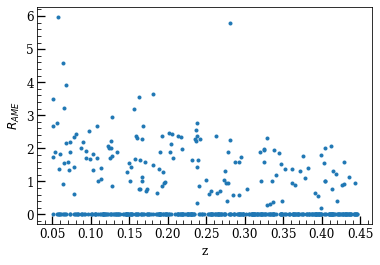

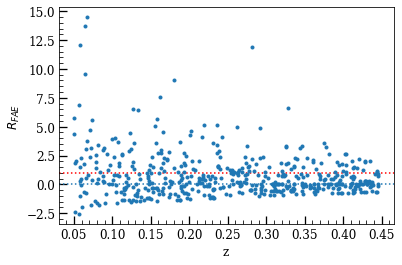

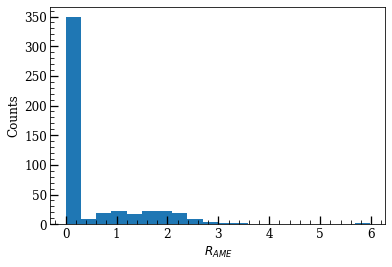

In [ ]:
plt.plot(random_detec['z'], rich_hdbs_r, '.')
plt.xlabel('z')
plt.ylabel('$R_{AME}$')
plt.show()

plt.axhline(0, ls=':')
plt.axhline(1, ls=':', color ='r')
plt.plot(random_detec['z'], richs_r, '.')
plt.xlabel('z')
plt.ylabel('$R_{FAE}$')
plt.show()

plt.hist(rich_hdbs_r, bins=20)
plt.xlabel('$R_{AME}$')
plt.ylabel('Counts')
plt.show()

## catalog run

In [ ]:
# load cluster catalog
cluster_catalog = Table.read('%s/cluster_catalog.fits'%path, format='fits')
cluster_catalog['ra'] = cluster_catalog['RA']
cluster_catalog['dec'] = cluster_catalog['DEC']
print(cluster_catalog.columns)


<TableColumns names=('ID','RA','DEC','z','z_err','SNR','SNR_ORIG','richness','radius','rank','ra','dec')>


In [ ]:
# catalog name
catalog_name = 'cluster_catalog_Rc'

# add column for Rc
cluster_catalog['Rc'] = (99.9)*len(cluster_catalog)

init = 0
for i in tqdm.tqdm(range(init, len(cluster_catalog))):

  # firts calculate knee radius (full galaxy data) 
  knee = radial_density_knee(data, cluster_catalog[i])
  cluster_catalog['Rc'][i] = knee

  if i%500 == 0: # temporary saving
    t = Table(cluster_catalog, names=cluster_catalog.columns)
    t.write('%s/%s_%s.fits'%(path, catalog_name, init), format='fits', overwrite=True)

t = Table(cluster_catalog, names=cluster_catalog.columns)
t.write('%s/%s_%s.fits'%(path, catalog_name, init), format='fits', overwrite=True)

100%|██████████| 1372/1372 [8:03:51<00:00, 21.16s/it]


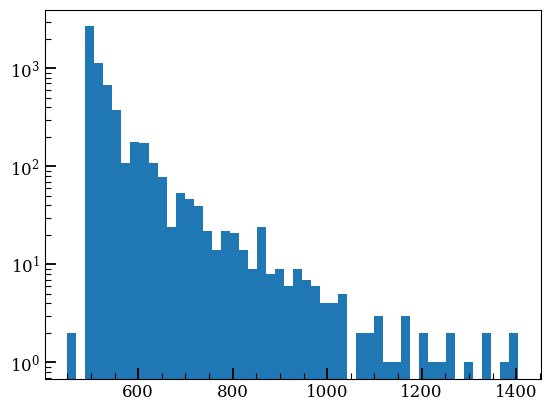

In [ ]:
plt.hist(cluster_catalog['Rc'], bins=50, log='true')
plt.show()

In [ ]:
# Load catalog with Rc
cluster_catalog = Table.read('%s/cluster_catalog_Rc.fits'%path, format='fits')
catalog_name = 'cluster_catalog_final'

# add absolute magnitude limit
cond =  data['M']< -20.25
data2 = data[cond]

# Load function parameters for field density
popt_mode, popt_err = (array([    67.21525287,   -922.03101932,  17794.94834135, -53971.06033017, 49796.302851  ]),
                       array([ 4.94373360e+01, -1.16140629e+03,  1.67950499e+04, -5.69143642e+04, 6.21688822e+04]))

# run catalog without substructures
cluster_catalog = run(cluster_catalog, data2, catalog_name, init=0, subs=0)

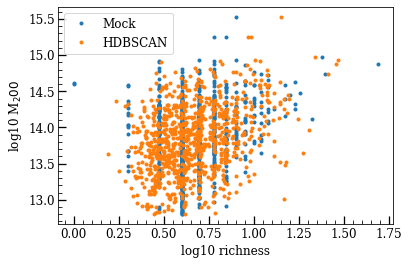

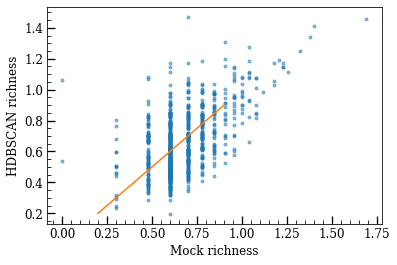

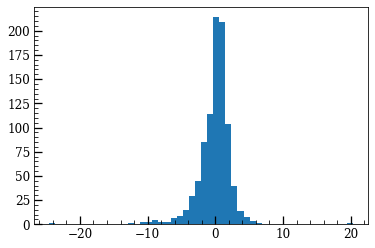

-82.3999999999998
0.1900000000000004 -0.09045005488474182
1.0699999999999994 2.407672540897214
0.018861217359339655 0.008657496487614621
0.11228290252157475 0.17251247962957292


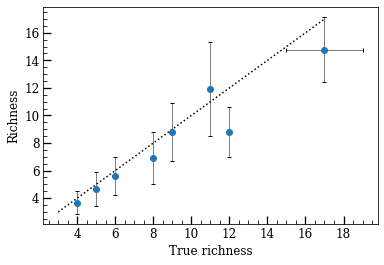

mean +/- std 0.8543750000000002 1.2118746776688594
median +/- mad 0.3600000000000003 0.44499999999999984
mean +/- std todos 0.008657496487614621 0.17251247962957292
median +/- mad todos 0.018861217359339655 0.11228290252157475


In [ ]:
# plot results comparing with mock catalog
X2_cil = log10(cluster_catalog['R_ame_mock']), log10(cluster_catalog['opt_lum_mock']), log10(cluster_catalog['opt_mass_mock'])
X22_cil = log10(cluster_catalog['R_ame']), log10(cluster_catalog['opt_lum']), log10(cluster_catalog['opt_mass'])
y2 = cluster_catalog['m']

cond = (X2_cil[0]>=log10(0)) & (X22_cil[0]>0)
X2 = [X2_cil[0][cond],X2_cil[1][cond]]
X22= [X22_cil[0][cond],X22_cil[1][cond]]
y = y2[cond]

plt.plot(X2[0], y,'.', label="Mock")
plt.plot(X22[0], y,'.', label="HDBSCAN")
plt.xlabel('log10 richness')
plt.ylabel('log10 M$_200$')
plt.legend()
plt.show()

plt.plot(X2[0], X22[0],'.', alpha = 0.5)
plt.plot(arange(0.2,1.,.1),arange(0.2,1.,.1))
plt.xlabel('Mock richness')
plt.ylabel('HDBSCAN richness')
plt.show()

diff = 10**X2[0]-10**X22[0]
plt.hist(diff,bins=50)
plt.show()

print(sum(diff))
print(median(diff),mean(diff))
print(median_absolute_deviation(diff), std(diff))

print(median(X2[0]-X22[0]),mean(X2[0]-X22[0]))
print(median_absolute_deviation(X2[0]-X22[0]), std(X2[0]-X22[0]))


bins = linspace(3,15,9)

med, v_med, frac = [], [], [] 
frac_err = []
v_med_err =[]
for i in range(len(bins)-1):
  if i < len(bins)-2: cond = (10**X2[0] >= bins[i]) & (10**X2[0] < bins[i+1])
  else: cond = (10**X2[0] >= bins[i])
  #print(i,len(X2[0][cond]))
  med += [ median(10**X2[0][cond]) ]
  #frac += [ median(diff[cond]) ]
  frac_err += [ median_absolute_deviation(10**X2[0][cond]) ]
  v_med += [median(10**X22[0][cond]) ]
  v_med_err += [ median_absolute_deviation(10**X22[0][cond]) ]


plt.errorbar(med, v_med, xerr=frac_err, yerr= v_med_err, color='k', fmt = 'none', capsize=2.0 , lw=0.5 )
plt.plot(arange(3,19,2), arange(3,19,2), ':', color='k')
plt.plot(med, v_med, 'o')
plt.ylabel('Richness')
plt.xlabel('True richness')
#plt.savefig('Rich_significance.pdf',format='pdf', bbox_inches = 'tight')
plt.show()


med, v_med = array(med), array(v_med)
med, v_med = array(med[med>=0]), array(v_med[med>=0])
print('mean +/- std',mean(med-v_med), std(med-v_med))
print('median +/- mad',median(med-v_med), median_absolute_deviation(med-v_med))

print('mean +/- std todos', mean(X2[0]-X22[0]), std(X2[0]-X22[0]))
print('median +/- mad todos', median(X2[0]-X22[0]), median_absolute_deviation(X2[0]-X22[0]))

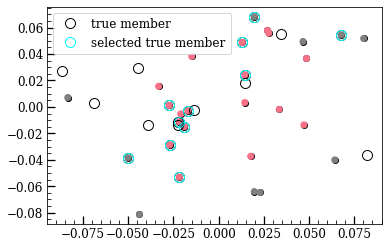

18.0 21
18.077387190268283 18.463538820997467


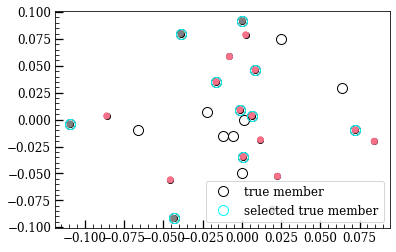

12.0 18
18.48677287361897 18.80586089853658


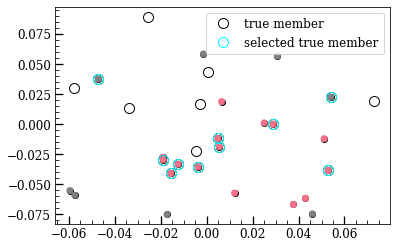

13.0 17
19.727031343780105 19.048858261156937


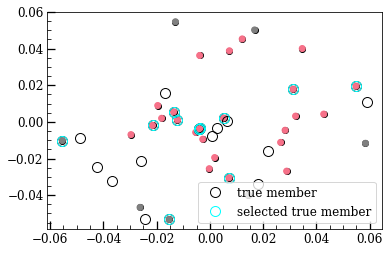

26.0 25
19.29093722752888 19.33001547558162


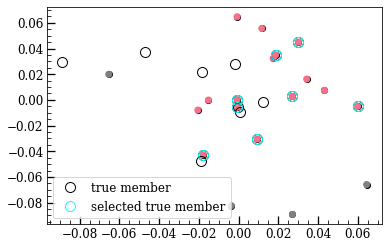

16.0 16
19.048682368749198 18.80293342364294


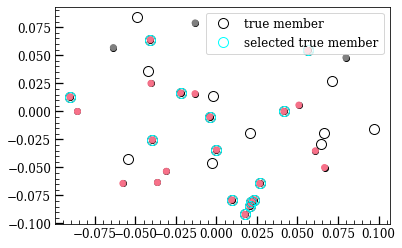

23.0 24
17.624629293575587 18.0284042286596


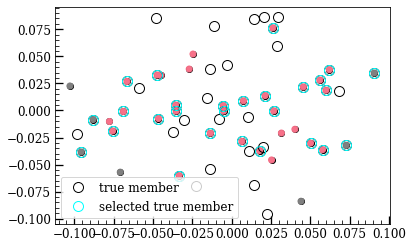

28.0 49
18.580847999354997 18.96503761868241


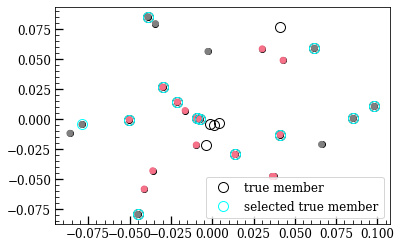

15.0 17
17.96733544049503 18.47406775107921


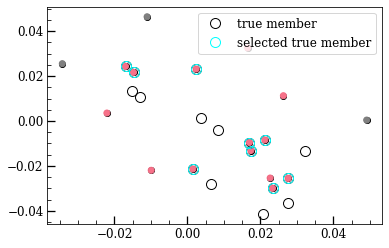

14.0 17
19.574065780591468 19.32698331839944


In [ ]:
# plotting detections with hdbscan only highlighting mock true members

cluster_catalog2 = cluster_catalog[cluster_catalog['R_ame_mock']>15]

for i in range(len(cluster_catalog2)):
  # hbdscan_run(data, cluster, dz, radius, N_runs, gradient, intercept, cluster_rich,
  #              substructure=0, is_mock=0, do_plot=0):
  out_data = hbdscan_run(data, cluster_catalog2[i], 0.05, cluster_catalog2['Rc'][i], 
                          1, 0.5292105368716316, 0.026652401872489406, cluster_catalog2['R_fae'][i],
                          substructure=0, is_mock=1, do_plot=1)
